# 01 — Data Exploration

Goal: download daily prices for **SPY** (stocks), **TLT** (long-term bonds) and **GLD** (gold), compute log returns, and look at how each asset behaves — especially in crises (2008, 2020, 2022). This intuition is what the regime model will formalize.

All logic lives in `src/data.py`; this notebook only calls it.

In [8]:
import sys
sys.path.append("..")  # let the notebook import from src/

import matplotlib.pyplot as plt
from src.data import download_prices, compute_returns, summary_stats

## 1. Load prices
The first run downloads from Yahoo Finance and saves `data/raw/prices.csv`. Later runs load that file, so results stay identical.

In [9]:
prices = download_prices()
print(prices.shape)
prices.tail()

(5449, 3)


,SPY,TLT,GLD
Date,,,
2026-08-25,764.012756,83.151375,428.070007
2026-08-26,764.182373,82.982025,421.320007
2026-08-27,769.189941,82.812668,422.600006
2026-08-28,767.444275,82.563622,408.890015
2026-08-31,765.149963,82.204994,408.420013


## 2. Growth of $1
Log scale, so equal vertical distances mean equal percentage moves.

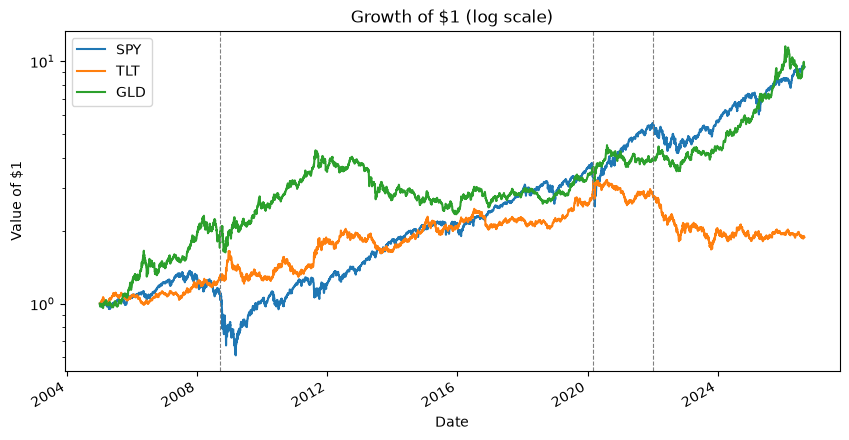

In [10]:
ax = (prices / prices.iloc[0]).plot(logy=True, figsize=(10, 5), title="Growth of $1 (log scale)")
for year in ["2008-09-15", "2020-03-01", "2022-01-01"]:
    ax.axvline(year, color="grey", linestyle="--", linewidth=0.8)
ax.set_ylabel("Value of $1")
plt.show()

## 3. Returns and summary statistics

In [11]:
returns = compute_returns(prices)
summary_stats(returns).round(3)

,ann_return,ann_vol,sharpe
SPY,0.104,0.189,0.549
TLT,0.029,0.145,0.201
GLD,0.104,0.183,0.569


## 4. Rolling volatility
Volatility clusters: calm periods stay calm, stressed periods stay stressed. That persistence is exactly what a regime model captures.

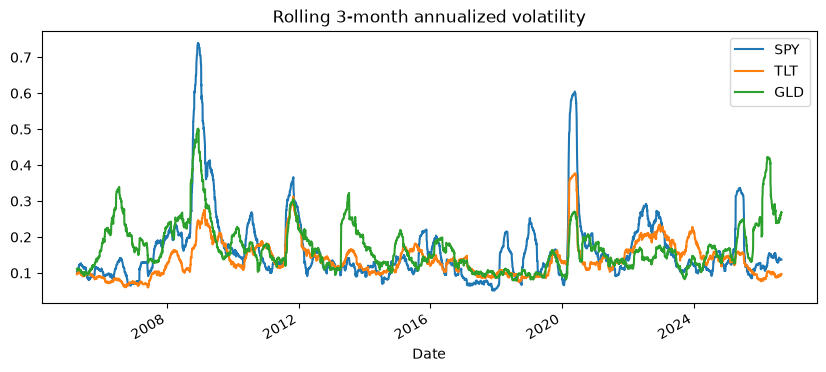

In [12]:
rolling_vol = returns.rolling(63).std() * (252 ** 0.5)  # ~3-month window, annualized
rolling_vol.plot(figsize=(10, 4), title="Rolling 3-month annualized volatility")
plt.show()

## 5. Correlation between assets
In stress, stocks and bonds often move in opposite directions — but not always (2022).

In [13]:
returns.corr().round(2)

,SPY,TLT,GLD
SPY,1.00,-0.30,0.07
TLT,-0.30,1.00,0.16
GLD,0.07,0.16,1.00


In [14]:
# Key numbers for the takeaways
print("Period:", prices.index[0].date(), "to", prices.index[-1].date(), "| trading days:", len(prices))

print("\nGrowth of $1 over the full period:")
print((prices.iloc[-1] / prices.iloc[0]).round(2))

drawdown = prices / prices.cummax() - 1
print("\nWorst drawdown (peak to bottom):")
print(drawdown.min().round(3))

crises = {
    "2008 financial crisis": ("2007-10-09", "2009-03-09"),
    "COVID crash":           ("2020-02-19", "2020-03-23"),
    "2022 rate hikes":       ("2022-01-03", "2022-10-12"),
}
for name, (start, end) in crises.items():
    p = prices.loc[start:end]
    print(f"\n{name} ({start} to {end}) return:")
    print((p.iloc[-1] / p.iloc[0] - 1).round(3))

print("\nAnnualized stats:")
print(summary_stats(returns).round(3))

print("\nCorrelations:")
print(returns.corr().round(2))

Period: 2005-01-03 to 2026-08-31 | trading days: 5449

Growth of $1 over the full period:
SPY    9.45
TLT    1.88
GLD    9.49
dtype: float64

Worst drawdown (peak to bottom):
SPY   -0.552
TLT   -0.484
GLD   -0.456
dtype: float64

2008 financial crisis (2007-10-09 to 2009-03-09) return:
SPY   -0.552
TLT    0.251
GLD    0.239
dtype: float64

COVID crash (2020-02-19 to 2020-03-23) return:
SPY   -0.337
TLT    0.142
GLD   -0.036
dtype: float64

2022 rate hikes (2022-01-03 to 2022-10-12) return:
SPY   -0.245
TLT   -0.293
GLD   -0.073
dtype: float64

Annualized stats:
     ann_return  ann_vol  sharpe
SPY       0.104    0.189   0.549
TLT       0.029    0.145   0.201
GLD       0.104    0.183   0.569

Correlations:
      SPY   TLT   GLD
SPY  1.00 -0.30  0.07
TLT -0.30  1.00  0.16
GLD  0.07  0.16  1.00


In [15]:
print("Date of worst drawdown:")
print(drawdown.idxmin())
print()
for name, (start, end) in crises.items():
    p = prices.loc[start:end]
    print(name, (p.iloc[-1] / p.iloc[0] - 1).round(3).to_dict())

Date of worst drawdown:
SPY   2009-03-09
TLT   2023-10-19
GLD   2015-12-17
dtype: datetime64[us]

2008 financial crisis {'SPY': -0.552, 'TLT': 0.251, 'GLD': 0.239}
COVID crash {'SPY': -0.337, 'TLT': 0.142, 'GLD': -0.036}
2022 rate hikes {'SPY': -0.245, 'TLT': -0.293, 'GLD': -0.073}


## Takeaways

- **Long run (2005–2026):** $1 grew to **$9.45 in SPY**, **$9.49 in GLD** and only **$1.88 in TLT**. SPY and GLD both returned ~10.4%/yr with similar volatility (Sharpe 0.55 vs 0.57); TLT's Sharpe was 0.20. Full-sample correlations: SPY–TLT **−0.30**, SPY–GLD **0.07**.
- **Crises differ.** In **2008** (SPY −55.2%), both TLT (+25.1%) and GLD (+23.9%) hedged. In **COVID 2020** (SPY −33.7%), only TLT hedged (+14.2%; GLD −3.6%). In **2022** (SPY −24.5%), TLT fell even more (−29.3%) and nothing protected the portfolio.
- **"Safe" assets have deep drawdowns too:** TLT −48.4% (bottom Oct 2023, rate-hike cycle), GLD −45.6% (bottom Dec 2015).
- **Volatility clusters:** SPY's rolling vol sits near 10–15% in calm years and spikes to ~74% (2008) and ~60% (2020), staying elevated for months.
- **Implication for the model:** stress comes in at least two types, *growth shocks* (bonds hedge) and *inflation/rate shocks* (bonds hurt). The regime model should use both stock and bond behavior to tell them apart, not stock volatility alone.